In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('df_final_demo_cleaned')
df = df.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['Unnamed: 0.1'])


In [11]:
df

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,169,21,262,47.5,M,2,501570.72,4,4
1,555,3,46,29.5,U,2,25454.66,2,6
2,647,12,151,57.5,M,2,30525.80,0,4
3,722,11,143,59.5,F,2,22466.17,1,1
4,934,9,109,51.0,F,2,32522.88,0,3
...,...,...,...,...,...,...,...,...,...
70590,9999400,7,86,28.5,U,2,51787.04,0,3
70591,9999626,9,113,35.0,M,2,36642.88,6,9
70592,9999729,10,124,31.0,F,3,107059.74,6,9
70593,9999832,23,281,49.0,F,2,431887.61,1,4


In [19]:
df_sorted_1 = df.sort_values(
    by=["bal","clnt_tenure_yr", "clnt_tenure_mnth", "calls_6_mnth", "logons_6_mnth"],
    ascending=[False, True,True, True,True],  
    ).head(int(0.1 * len(df)))
df_sorted_1

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
65646,9286288,21,254,62.5,M,3,16320040.15,6,9
59004,8339240,6,80,26.5,M,2,12838418.01,3,3
49990,7070097,11,133,53.0,M,2,8986419.77,6,9
66709,9440656,7,94,63.0,F,2,8292996.21,6,9
16057,2291985,7,85,41.0,M,2,8247729.97,1,4
...,...,...,...,...,...,...,...,...,...
21242,3032988,10,131,47.5,M,2,319589.21,2,5
47978,6787766,24,294,63.5,U,3,319554.04,6,9
3992,563689,22,269,55.0,M,3,319553.03,2,5
47335,6702347,5,66,65.5,U,2,319497.50,6,9


In [29]:
balance_threshold = df["bal"].quantile(0.90)  
login_threshold = df["logons_6_mnth"].quantile(0.90)  

df["primary_client"] = (
    (df["bal"] >= balance_threshold) &
    (df["logons_6_mnth"] >= login_threshold)
)

In [30]:
df

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,primary_client
0,169,21,262,47.5,M,2,501570.72,4,4,False
1,555,3,46,29.5,U,2,25454.66,2,6,False
2,647,12,151,57.5,M,2,30525.80,0,4,False
3,722,11,143,59.5,F,2,22466.17,1,1,False
4,934,9,109,51.0,F,2,32522.88,0,3,False
...,...,...,...,...,...,...,...,...,...,...
70590,9999400,7,86,28.5,U,2,51787.04,0,3,False
70591,9999626,9,113,35.0,M,2,36642.88,6,9,False
70592,9999729,10,124,31.0,F,3,107059.74,6,9,False
70593,9999832,23,281,49.0,F,2,431887.61,1,4,False


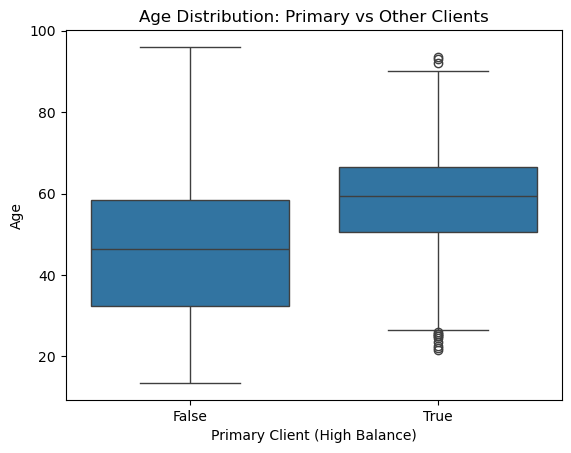

In [31]:
sns.boxplot(x="primary_client", y="clnt_age", data=df)
plt.xlabel("Primary Client (High Balance)")
plt.ylabel("Age")
plt.title("Age Distribution: Primary vs Other Clients")
plt.show()

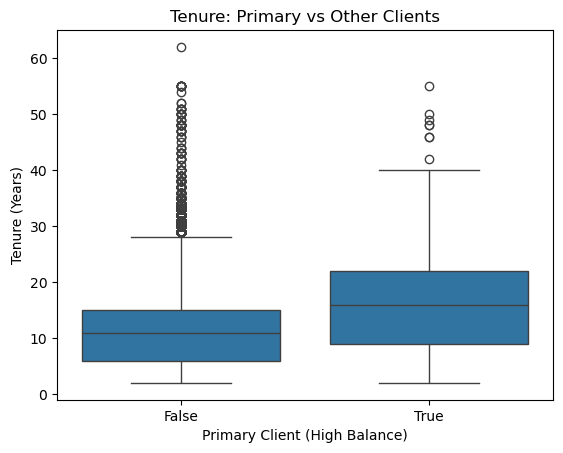

In [32]:
sns.boxplot(x="primary_client", y="clnt_tenure_yr", data=df)
plt.xlabel("Primary Client (High Balance)")
plt.ylabel("Tenure (Years)")
plt.title("Tenure: Primary vs Other Clients")
plt.show()

In [36]:
quartiles, bins = pd.qcut(df["clnt_age"], 4, labels=["Q1", "Q2", "Q3", "Q4"], retbins=True)
df["age_quartile"] = quartiles
mean_bal_per_quartile = df.groupby("age_quartile")["bal"].mean().reset_index()

C:\Users\jorgi\AppData\Local\Temp\ipykernel_21816\1831060422.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bal_per_quartile = df.groupby("age_quartile")["bal"].mean().reset_index()


C:\Users\jorgi\AppData\Local\Temp\ipykernel_21816\2085111163.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\jorgi\AppData\Local\Temp\ipykernel_21816\2085111163.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_with_ranges)


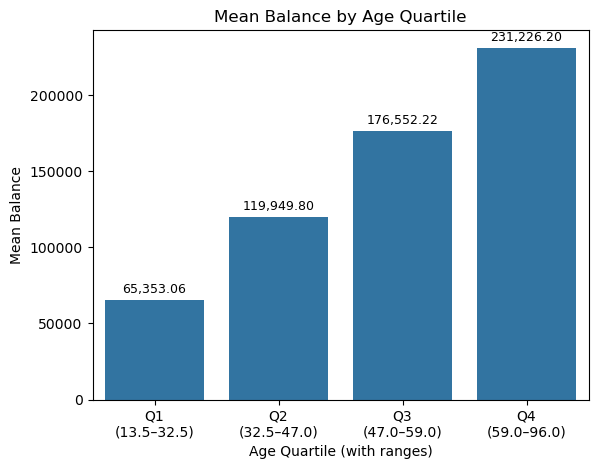

In [38]:
ax = sns.barplot(
    x="age_quartile",
    y="bal",
    data=df,
    estimator="mean",
    ci=None
)

# Replace tick labels with Q + age range
labels_with_ranges = [
    f"Q{i+1}\n({bins[i]:.1f}–{bins[i+1]:.1f})" for i in range(len(bins)-1)
]
ax.set_xticklabels(labels_with_ranges)

# Add mean balance values above bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=9, color='black',
        xytext=(0, 3), textcoords='offset points'
    )

# Labels and title
plt.xlabel("Age Quartile (with ranges)")
plt.ylabel("Mean Balance")
plt.title("Mean Balance by Age Quartile")
plt.show()

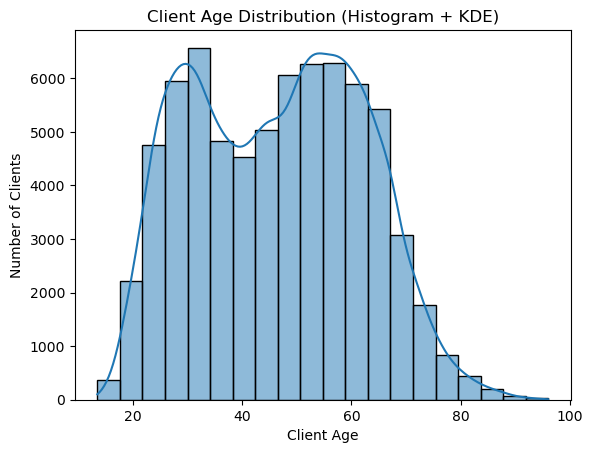

In [42]:
sns.histplot(df["clnt_age"], bins=20, kde=True)
plt.xlabel("Client Age")
plt.ylabel("Number of Clients")
plt.title("Client Age Distribution (Histogram + KDE)")
plt.show()

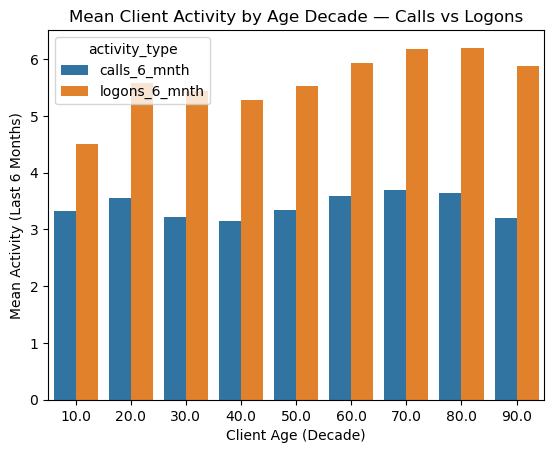

In [46]:
df["age_decade"] = (df["clnt_age"] // 10) * 10  # e.g., 47.5 -> 40, 32.0 -> 30

# Calculate mean calls and logons per decade
activity_by_decade = (
    df.groupby("age_decade")[["calls_6_mnth", "logons_6_mnth"]]
      .mean()
      .reset_index()
)

# Melt into long format for easier plotting
activity_melted = activity_by_decade.melt(
    id_vars="age_decade",
    value_vars=["calls_6_mnth", "logons_6_mnth"],
    var_name="activity_type",
    value_name="mean_activity"
)

# Plot
sns.barplot(
    x="age_decade",
    y="mean_activity",
    hue="activity_type",
    data=activity_melted
)
plt.xlabel("Client Age (Decade)")
plt.ylabel("Mean Activity (Last 6 Months)")
plt.title("Mean Client Activity by Age Decade — Calls vs Logons")
plt.show()